<a href="https://colab.research.google.com/github/Swastika-Roy/Python-concepts/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score
#set the style for seaborn plots

sns.set(style='whitegrid')

In [4]:
##load iris dataset (binary classification)

iris = load_iris()
X = iris.data[:,:2]
y=(iris.target==0).astype(int)
df=pd.DataFrame(X,columns=['Sepal length','Sepal width'])
df['target']=y
df.head()

,Sepal length,Sepal width,target
0,5.1,3.5,1
1,4.9,3.0,1
2,4.7,3.2,1
3,4.6,3.1,1
4,5.0,3.6,1


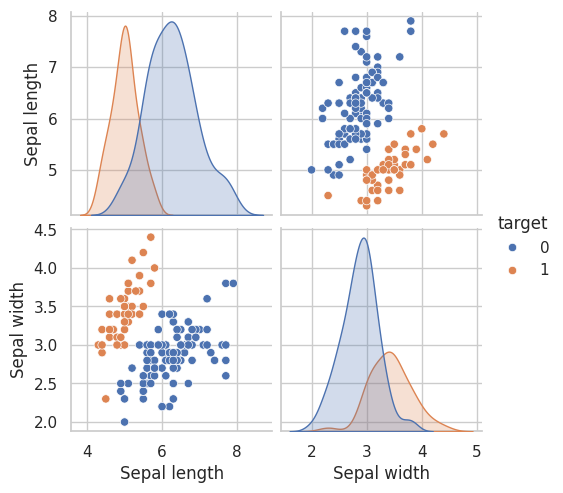

In [5]:
#Pairplot - feature relationships
sns.pairplot(df,hue='target')
plt.show()

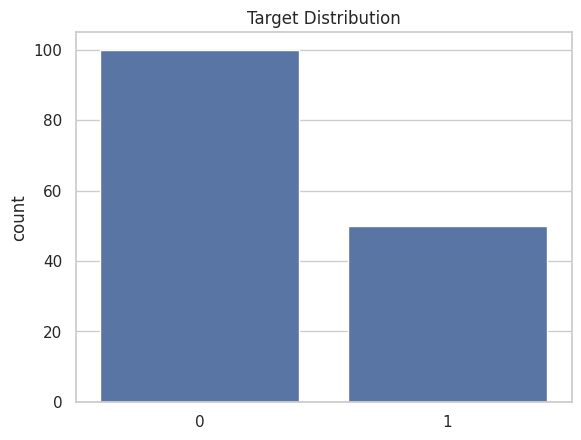

In [6]:
#target distribution
sns.countplot(x=y)
plt.title('Target Distribution')
plt.show()

In [7]:
#train-test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
X_train.shape,X_test.shape

((105, 2), (45, 2))

In [11]:
##Train logistic regression model
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [12]:
#model coefficients and intercept
model.coef_,model.intercept_

(array([[-3.02770236,  2.7360158 ]]), array([7.52147839]))

In [13]:
#predictions and accuracy
y_pred=model.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

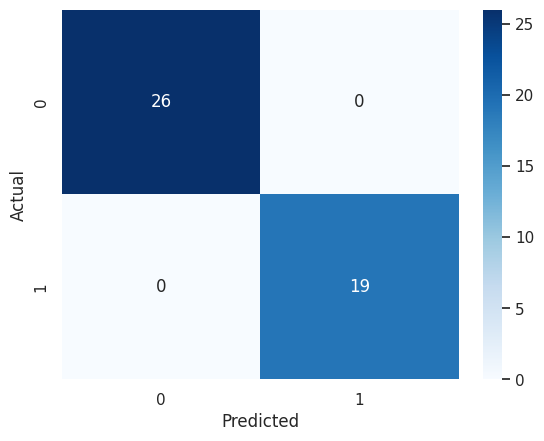

In [14]:
#confusion  matrix
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
##classifiaction report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        19

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [16]:
## predict probabilities
y_prob=model.predict_proba(X_test)[:,1]

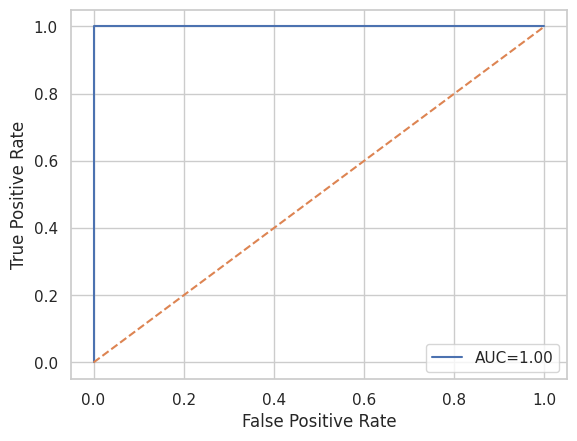

In [17]:
##ROC CURVE AND AUC
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test,y_prob)
plt.plot(fpr,tpr,label=f'AUC={auc:.2f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [19]:
## Manual Confusion Matrix calculation
y_true = np.array([1,0,1,1,0,1,0,0,1,0])
y_pred = np.array([1,0,1,0,0,1,0,1,0,0])
TP = np.sum((y_true == 1) & (y_pred == 1))
TN = np.sum((y_true == 0) & (y_pred == 0))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))
print(f'TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}')

TP: 3, TN: 4, FP: 1, FN: 2


In [20]:
#Manual ROC Curve Calculation
sorted_indices = np.argsort(y_prob)[::-1]
y_sorted = y_test[sorted_indices]


In [24]:
TPR,FPR=[],[]
P = sum(y_test)
N = len(y_test) - P

In [26]:
tp = fp = 0
for label in y_sorted:
    if label == 1:
        tp += 1
    else:
        fp += 1
    TPR.append(tp / P)
    FPR.append(fp / N)

len(TPR),len(FPR)


(90, 90)

In [27]:
#manual auc calculation
auc_manual = np.trapz(TPR,FPR)
auc_manual

/tmp/ipython-input-4027812489.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_manual = np.trapz(TPR,FPR)


np.float64(1.4736842105263155)

In [29]:
## decision boundary
x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
y_min,y_max=X[:,1].min()-1,X[:,1].max()+1



In [31]:
xx,yy = np.meshgrid(
    np.linspace(x_min,x_max,200),
    np.linspace(y_min,y_max,200))

In [32]:
Z = model.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

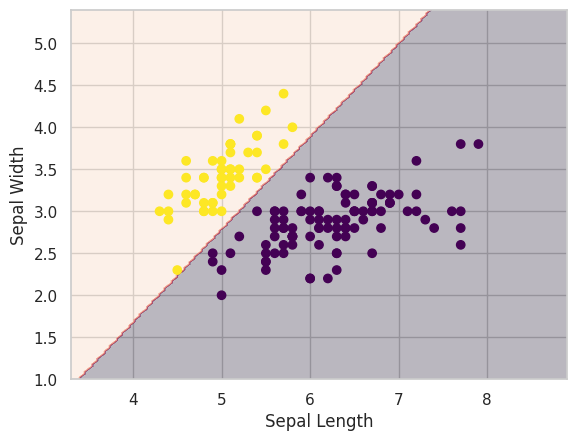

In [34]:
plt.contourf(xx,yy,Z,alpha=0.3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show('Decision Boundary')


In [35]:
from sklearn.metrics import classification_report

y_true = [1,0,1,1,0,1,0,0,1,0]
y_pred = [1,0,1,0,0,1,0,1,0,0]

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.75      0.60      0.67         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



In [36]:
import numpy as np

y_true = np.array([1,0,1,1,0,1,0,0,1,0])
y_pred = np.array([1,0,1,0,0,1,0,1,0,0])

TP = np.sum((y_true == 1) & (y_pred == 1))
TN = np.sum((y_true == 0) & (y_pred == 0))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))



In [40]:
precision = TP / (TP+FP)# Correct predictions
recall = TP/(TP+FN)#Positive coverage
f1 = 2 * (precision * recall) / (precision + recall)#Harmonic mean Balance

In [41]:
TP,TN,FP,FN,precision,recall,f1

(np.int64(3),
 np.int64(4),
 np.int64(1),
 np.int64(2),
 np.float64(0.75),
 np.float64(0.6),
 np.float64(0.6666666666666665))

In [ ]:
##Load Iris Dataset (Binary Classification)
iris = load_iris()